In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('titanic_data.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [4]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [5]:
df.isnull().sum()
# df.drop(['Cabin'],axis=1,inplace=True)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [6]:
X = df.drop(['Survived'],axis=1)

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [7]:
y = df['Survived']

y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train
display(y_train)

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [10]:
X_test
display(y_test)

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

In [11]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [12]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age          37
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [13]:
#mean impute

age_mean = X_train['Age'].mean()

X_train['age_mean_imputor'] = X_train['Age'].fillna(age_mean)

X_test['age_mean_imputor'] = X_test['Age'].fillna(age_mean)


In [14]:
#median impute

age_median = X_train['Age'].median()


X_train['age_median_imputor'] = X_train['Age'].fillna(age_median)

X_test['age_median_imputor'] = X_test['Age'].fillna(age_median)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputor,age_median_imputor
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.0
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,28.0
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.0
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.0


<Axes: xlabel='age_mean_imputor', ylabel='Density'>

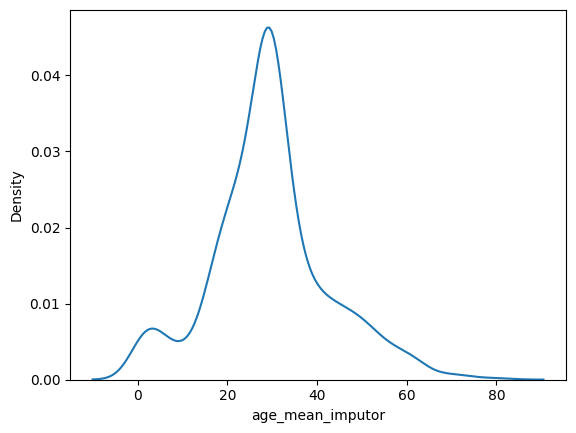

In [15]:
sns.kdeplot(data=X_train , x='age_mean_imputor')

<Axes: xlabel='age_median_imputor', ylabel='Density'>

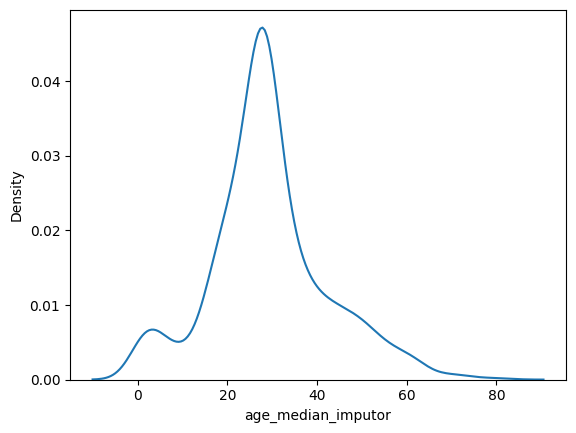

In [16]:
sns.kdeplot(data=X_train , x='age_median_imputor')

In [17]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(missing_values=np.nan , strategy='mean')

age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()




In [18]:
X_train.isnull().sum()

X_train.drop(['age_mean_imputor','age_median_imputor'],axis=1,inplace=True)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,NaN,S
382,third,male,32.000000,0,0,7.9250,NaN,S
704,third,male,26.000000,1,0,7.8542,NaN,S
813,third,female,6.000000,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S
270,first,male,29.498846,0,0,31.0000,NaN,S
860,third,male,41.000000,2,0,14.1083,NaN,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [19]:
X_test['Age'] = age_imputer.transform(X_test[['Age']])

X_test.isnull().sum()

Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Cabin                 134
Embarked                0
age_mean_imputor        0
age_median_imputor      0
dtype: int64

In [20]:
X_test.drop(['age_mean_imputor','age_median_imputor'],axis=1,inplace=True)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


In [21]:
embarked_imputer = SimpleImputer(missing_values=np.nan , strategy='most_frequent')

embarked_imputer.fit(X_train[['Embarked']])

# transform both train and test data

X_train['Embarked']= embarked_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embarked_imputer.transform(X_test[['Embarked']]).ravel()




In [22]:
X_train.isnull().sum()
X_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [ ]:
sns.countplot(data = X_train , x=X_train['Cabin'])

<Axes: xlabel='Cabin', ylabel='count'>

In [ ]:
cabin_imputer = SimpleImputer(missing_values=np.nan , strategy='constant',fill_value='Missing',add_indicator=True)

cabin_imputer.fit(X_train[['Cabin']])

# transform both train and test data

X_train[['Cabin','cabin_missing_indicator']]= cabin_imputer.transform(X_train[['Cabin']])
X_test[['Cabin','cabin_missing_indicator']] = cabin_imputer.transform(X_test[['Cabin']])

In [ ]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False


In [ ]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
709,third,male,29.498846,1,1,15.2458,Missing,C,True
439,second,male,31.000000,0,0,10.5000,Missing,S,True
840,third,male,20.000000,0,0,7.9250,Missing,S,True
720,second,female,6.000000,0,1,33.0000,Missing,S,True
39,third,female,14.000000,1,0,11.2417,Missing,C,True
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True
773,third,male,29.498846,0,0,7.2250,Missing,C,True
25,third,female,38.000000,1,5,31.3875,Missing,S,True
84,second,female,17.000000,0,0,10.5000,Missing,S,True


In [ ]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
cabin_missing_indicator,0


In [ ]:
X_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
cabin_missing_indicator,0


# Outlier Detection

## Using Z-Score

In [ ]:
mean_of_age = X_train['Age'].mean()
std_of_age = X_train['Age'].std()
X_train['zscore_Age'] = (X_train['Age']-mean_of_age)/std_of_age


X_train


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00


In [ ]:
outliers_age = X_train[abs(X_train['zscore_Age']) >3]

print(len(outliers_age))

display(outliers_age)

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age
116,third,male,70.5,0,0,7.750,Missing,Q,True,3.155317
745,first,male,70.0,1,1,71.000,B22,S,False,3.116839
630,first,male,80.0,0,0,30.000,A23,S,False,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,True,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,True,3.116839


In [ ]:
mean_of_fare = X_train['Fare'].mean()
std_of_fare = X_train['Fare'].std()

X_train['zscore_Fare'] = (X_train['Fare']-mean_of_fare)/std_of_fare


X_train


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [ ]:
outliers_fare = X_train[abs(X_train['zscore_Fare']) >3]

print(len(outliers_fare))

display(outliers_fare)

17


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
118,first,male,24.000000,0,1,247.5208,B58 B60,C,False,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,False,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,False,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,False,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,True,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,False,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,False,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,False,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,False,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,True,2.734055e-16,3.751020


## Outliers with IQR

In [ ]:
# age

age_Q1 = X_train['Age'].quantile(0.25)
age_Q3 = X_train['Age'].quantile(0.75)

age_IQR = age_Q3 - age_Q1

age_minimum = age_Q1 - 1.5 * age_IQR
age_maximum = age_Q3 + 1.5 * age_IQR

print(age_minimum , age_maximum)



2.5 54.5


In [ ]:
age_outlier_IQR = X_train[(X_train['Age']<age_minimum) | (X_train['Age']>age_maximum)]

print(len(age_outlier_IQR))
display(age_outlier_IQR)

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
326,third,male,61.00,0,0,6.2375,Missing,S,True,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,True,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,True,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,False,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,False,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,True,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,False,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,True,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,True,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,True,-2.193180,-0.324124


In [ ]:
# fare

fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

fare_IQR = fare_Q3 - fare_Q1

fare_minimum = max(0,fare_Q1 - 1.5 * fare_IQR)
fare_maximum = fare_Q3 + 1.5 * fare_IQR

print(fare_minimum , fare_maximum)


0 64.3625


In [ ]:
fare_outlier_IQR = X_train[(X_train['Fare']<fare_minimum) | (X_train['Fare']>fare_maximum)]

print(len(fare_outlier_IQR))
display(fare_outlier_IQR)

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,False,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,False,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,False,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,False,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,False,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,False,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,True,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,False,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,False,-1.192742,1.682019


In [ ]:
# z score outlier detection is better for age outliers

# zscore jader 3 er choto ba shoman shudhu matro tader kei amra train e rakhtesi
X_train = X_train[abs(X_train['zscore_Age']) <=3]

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [ ]:
minimum_zscore_fare = X_train[abs(X_train['zscore_Fare']) <=3]['Fare'].max()

print((minimum_zscore_fare))

164.8667


In [ ]:
X_train['Fare']= X_train['Fare'].clip(fare_minimum , fare_maximum)

X_train['Fare'].max()

/tmp/ipykernel_827/1394324696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Fare']= X_train['Fare'].clip(fare_minimum , fare_maximum)


64.3625

In [ ]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,-1.192742e+00,1.682019


In [ ]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,-1.192742e+00,1.682019


In [ ]:
X_train.drop(['zscore_Age','zscore_Fare'],axis=1 , inplace=True)

X_train

/tmp/ipykernel_827/1674476712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['zscore_Age','zscore_Fare'],axis=1 , inplace=True)


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False


In [ ]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

pclass_encoder = OrdinalEncoder(categories=[['third','second','first']])

pclass_encoder.fit(X_train[['Pclass']])

#transform

X_train['encoded_Pclass'] = pclass_encoder.transform(X_train[['Pclass']]).ravel()
X_test['encoded_Pclass'] = pclass_encoder.transform(X_test[['Pclass']]).ravel()


X_test

/tmp/ipykernel_827/356324151.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['encoded_Pclass'] = pclass_encoder.transform(X_train[['Pclass']]).ravel()


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0
...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0


In [ ]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0


In [ ]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0


In [ ]:
embarked_ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

embarked_ohe.fit(X_train[['Embarked']])


encoded_df = embarked_ohe.transform(X_train[['Embarked']])
X_train = pd.concat([X_train,encoded_df],axis =1)



In [ ]:
# transforming test data
encoded_df = embarked_ohe.transform(X_test[['Embarked']])
X_test = pd.concat([X_test,encoded_df],axis =1)

In [ ]:
X_train.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S
694,first,male,60.000000,0,0,26.5500,Missing,S,True,2.0,0.0,0.0,1.0
195,first,female,58.000000,0,0,64.3625,B80,C,False,2.0,1.0,0.0,0.0
586,second,male,47.000000,0,0,15.0000,Missing,S,True,1.0,0.0,0.0,1.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,0.0,1.0


In [ ]:
X_train.drop(['Pclass','Sex','Embarked'],axis=1 , inplace= True)

In [ ]:
X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,0.0,1.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,0.0,1.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,0.0,1.0
813,6.000000,4,2,31.2750,Missing,True,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,0.0,0.0,1.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,0.0,1.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,0.0,1.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,0.0,0.0,1.0


In [ ]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,1.0,0.0,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0,0.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0,0.0,0.0,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0,1.0,0.0,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,0.0,0.0,1.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0,0.0,0.0,1.0


In [ ]:
X_test.drop(['Pclass','Sex','Embarked'],axis=1 , inplace= True)

In [ ]:
X_test

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S
709,29.498846,1,1,15.2458,Missing,True,0.0,1.0,0.0,0.0
439,31.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0
720,6.000000,0,1,33.0000,Missing,True,1.0,0.0,0.0,1.0
39,14.000000,1,0,11.2417,Missing,True,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,0.0,1.0
773,29.498846,0,0,7.2250,Missing,True,0.0,1.0,0.0,0.0
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,0.0,1.0
84,17.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0


In [ ]:
X_train['Cabin'].value_counts()

,count
Cabin,
Missing,550
C23 C25 C27,4
C22 C26,3
B96 B98,3
F2,3
...,...
A14,1
D49,1
C87,1


In [ ]:
X_train['Cabin'].dtype

dtype('O')

In [ ]:
X_train['Cabin_Deck'] = X_train['Cabin'].astype(str).str[0]

X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,0.0,1.0,C
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,0.0,1.0,M
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0,M
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,0.0,1.0,M
813,6.000000,4,2,31.2750,Missing,True,0.0,0.0,0.0,1.0,M
...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,0.0,0.0,1.0,M
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,0.0,1.0,M
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,0.0,1.0,M
435,14.000000,1,2,64.3625,B96 B98,False,2.0,0.0,0.0,1.0,B


In [ ]:
X_train['Cabin_Deck'].value_counts()

,count
Cabin_Deck,
M,550
C,52
B,37
E,24
D,19
F,12
A,9
G,3
T,1


In [ ]:
X_test['Cabin_Deck'] = X_test['Cabin'].astype(str).str[0]

In [ ]:
deck_ohe = OneHotEncoder(sparse_output=False,drop='first').set_output(transform='pandas')

deck_ohe.fit(X_train[['Cabin_Deck']])


encoded_df = deck_ohe.transform(X_train[['Cabin_Deck']])
X_train = pd.concat([X_train,encoded_df],axis =1)

X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,0.0,1.0,C,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,Missing,True,0.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,0.0,0.0,1.0,B,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
encoded_df = deck_ohe.transform(X_test[['Cabin_Deck']])
X_test = pd.concat([X_test,encoded_df],axis =1)

X_test

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
709,29.498846,1,1,15.2458,Missing,True,0.0,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
439,31.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
840,20.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
720,6.000000,0,1,33.0000,Missing,True,1.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39,14.000000,1,0,11.2417,Missing,True,0.0,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,True,0.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
773,29.498846,0,0,7.2250,Missing,True,0.0,1.0,0.0,0.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25,38.000000,1,5,31.3875,Missing,True,0.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
84,17.000000,0,0,10.5000,Missing,True,1.0,0.0,0.0,1.0,M,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X_train.drop('Cabin_Deck',axis=1, inplace=True)
X_test.drop('Cabin_Deck',axis=1, inplace=True)

In [ ]:
X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,C124,False,2.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,Missing,True,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,21.000000,0,0,7.6500,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,Missing,True,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,41.000000,2,0,14.1083,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,14.000000,1,2,64.3625,B96 B98,False,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y_train


,Survived
331,no
733,no
382,no
704,no
813,no
...,...
106,yes
270,no
860,no
435,yes


In [ ]:
#label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# fit

le.fit(y_train)

#transform

y_train_array = le.transform(y_train)
y_test_array = le.transform(y_test)

In [ ]:
y_train = pd.Series(y_train_array,index = y_train.index , name = y_train.name)
y_test = pd.Series(y_test_array,index = y_test.index , name = y_test.name)

In [ ]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


<Axes: xlabel='Age', ylabel='Density'>

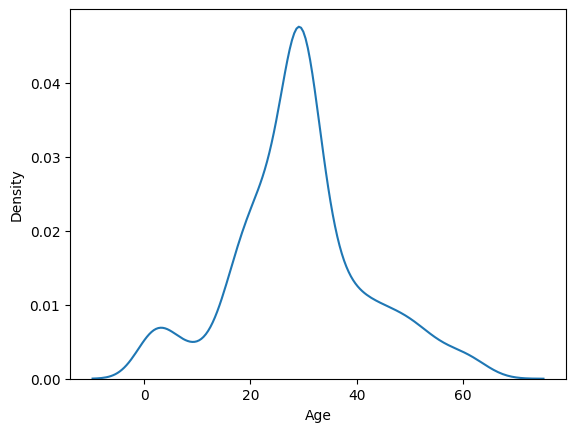

In [ ]:
sns.kdeplot(data = X_train , x ='Age')

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(X_train[['Age']])

X_train['Age'] = ss.transform(X_train[['Age']]).ravel()
X_test['Age'] = ss.transform(X_test[['Age']]).ravel()

In [ ]:
X_train.sample(5)

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
189,0.544584,0,0,7.8958,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
884,-0.335313,0,0,7.0500,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
536,1.264499,0,0,26.5500,B38,False,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
179,0.544584,0,0,0.0000,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
519,0.224621,0,0,7.8958,Missing,True,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
round(X_train['Age'].mean(),5)

np.float64(0.0)

In [ ]:
round(X_train['Age'].std(),5)

1.00071

<Axes: xlabel='Age', ylabel='Density'>

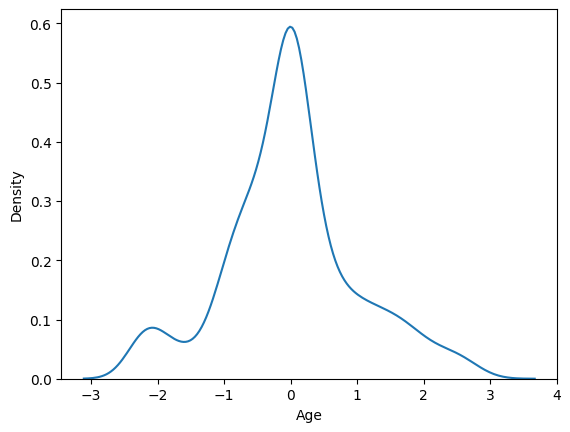

In [ ]:
sns.kdeplot(data = X_train , x ='Age')

<Axes: xlabel='Fare', ylabel='Density'>

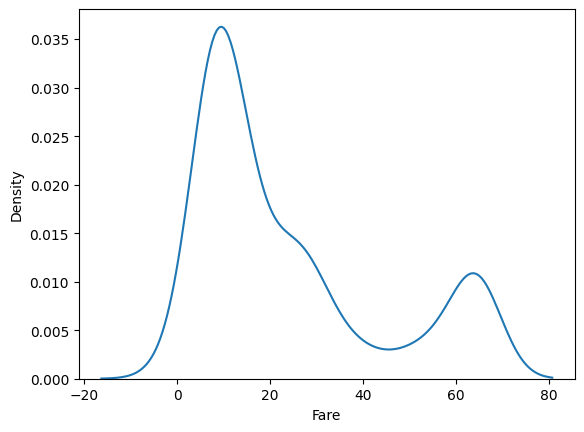

In [ ]:
sns.kdeplot(data = X_train , x='Fare')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

mms.fit(X_train[['Fare']])

X_train['Fare'] = mms.transform(X_train[['Fare']]).ravel()
X_test['Fare'] = mms.transform(X_test[['Fare']]).ravel()

In [ ]:
X_train['Fare'].describe()

,Fare
count,707.000000
mean,0.368633
std,0.313162
min,0.000000
25%,0.123131
50%,0.224575
75%,0.473878
max,1.000000


<Axes: xlabel='Fare', ylabel='Density'>

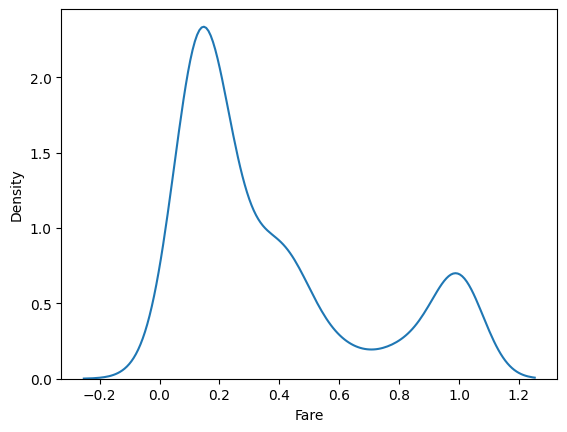

In [ ]:
sns.kdeplot(data = X_train , x='Fare')